<table>
    <tr>
        <td><img src="https://raw.githubusercontent.com/Fabian830348/Bases_Datos/refs/heads/master/logo_ECI.png" width="300"/></td>
        <td>&nbsp;</td>
        <td>
            <h1 style="font-size:200%;color:blue;text-align:center">    <FONT COLOR="blue">  Entregable   </p> K-means y PCA </FONT>         </h1></td>         
        <td>
            <tp><p style="font-size:99%;text-align:center">Aprendizaje Automático de Máquina </p></tp>
            <tp><p style="font-size:115%;text-align:center">Pregrado MACC 2026-1</p></tp>
            <tp><p style="font-size:115%;text-align:center">Prof. Fabián Sánchez</p></tp>
        </td>
    </tr>
</table>

In [136]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# <FONT SIZE=5 COLOR="purple"> **Indicaciones** </FONT>

- Para entregar en grupo

- **Importante:** Cargar en la plataforma *e-aulas* los **dos** archivos: ***.ipynb*** y ***.pdf***

- Fecha de entrega el día **lunes 10 de nov 6:00 p.m.**



# <FONT COLOR="Purple"> 1. Clustering k-means </FONT>

Para este ejercicio considere los datos que contiene información sobre:

   - *CustomerID* : Identificación del cliente
   - *Gender* : Genero, Masculino o Femenino
   - *Age* : Edad
   - *Annual Income*: Ingresos anuales en miles de $.
   - *Spending Score* : Puntos de Gastos (1-100)

Esta última variable se asigna al cliente en función de algunos parámetros, como el comportamiento del cliente y los datos de compra.

url ="https://raw.githubusercontent.com/Fabian830348/Bases_Datos/refs/heads/master/customers_clustering.csv"

El objetivo es hacer *segmentación* usando el método de *k-means clustering*.

La segmentación es un proceso que se utiliza en la investigación de mercado para dividir a los clientes en diferentes grupos o segmentos de acuerdo con un determinado conjunto de características.

1. Cargar los datos

2. Hacer exploración de las variables y su comportamiento. Use frecuencias, histogramas, boxplot, según considere necesario.

Considere el conjunto de datos sin la variable categórica; *gender*

3. Seleccione un valor de $k$ (número de cluster) y aplique k-means. Utilice boxplot y gráficos 3D para interpretar.

4. Utilice el método del codo y de la silueta para determinar cuál es el valor de $k$ óptimo (recuerde que esos métodos pueden sugerir diferentes valores de $k$).

5. Aplique de nuevo k-means. Utilice boxplot y gráficos 3D para interpretar.

6. ¿Cuál es el representante de cada cluster y los vecinos más cercanos a este?

Repita el ejercicio de *kmeans* incluyendo la variable *Gender*. ¿Cambian los resultados? Interprete.

7. Analice y concluya.

In [137]:
import numpy  as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn           as sns
import plotly.express    as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics       import silhouette_score, silhouette_samples
from sklearn.cluster       import KMeans
from sklearn.neighbors     import NearestNeighbors
from sklearn.metrics       import pairwise_distances_argmin_min

from yellowbrick.cluster import KElbowVisualizer

import warnings
warnings.filterwarnings("ignore")

In [138]:
url = "https://raw.githubusercontent.com/Fabian830348/Bases_Datos/refs/heads/master/customers_clustering.csv"
clientes = pd.read_csv(url)
clientes.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [139]:
clientes.shape

(200, 5)

In [140]:
clientes.info

<bound method DataFrame.info of      CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0             1    Male   19                  15                      39
1             2    Male   21                  15                      81
2             3  Female   20                  16                       6
3             4  Female   23                  16                      77
4             5  Female   31                  17                      40
..          ...     ...  ...                 ...                     ...
195         196  Female   35                 120                      79
196         197  Female   45                 126                      28
197         198    Male   32                 126                      74
198         199    Male   32                 137                      18
199         200    Male   30                 137                      83

[200 rows x 5 columns]>

In [141]:
clientes.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


## <FONT SIZE=4 COLOR="green"> 2 Exploracion de variables </FONT>

In [142]:
clientes['Gender'].value_counts()

,count
Gender,
Female,112
Male,88


In [143]:
def boxplots_variables_numericas_plotly(df):
    # Seleccionar solo las columnas numéricas y excluir 'CustomerID' si existe
    df_numerico = df.select_dtypes(include=['number']).drop(columns=['CustomerID'], errors='ignore')

    # Convertir el DataFrame en formato largo para que Plotly pueda graficar
    df_long = df_numerico.melt(var_name='Variable', value_name='Valor')

    # Crear el boxplot con Plotly Express
    fig = px.box(df_long,
                 x='Variable',
                 y='Valor',
                 color='Variable',
                 title='Boxplots de Variables Numéricas (sin CustomerID)')
    fig.update_layout(xaxis_title='Variables', yaxis_title='Valores')
    fig.show()

## <FONT SIZE=4 COLOR="green"> 3. K-means sin la variable gender </FONT>

In [144]:
#solo variables numericas
df_num = clientes.select_dtypes(include=['number']).drop(columns=['CustomerID'])
# Escalamos los datos
scaler = StandardScaler()
scaler.fit(df_num)
df = pd.DataFrame(scaler.transform(df_num),
                  columns=df_num.columns)
df.head(6)

,Age,Annual Income (k$),Spending Score (1-100)
0,-1.424569,-1.738999,-0.434801
1,-1.281035,-1.738999,1.195704
2,-1.352802,-1.700830,-1.715913
3,-1.137502,-1.700830,1.040418
4,-0.563369,-1.662660,-0.395980
5,-1.209269,-1.662660,1.001596


In [145]:
# generación del modelo con dos clusters
n = 3
kmeans = KMeans(n_clusters=n,                  #Número de clusters
                random_state=0)                #Semilla aleatoria.
kmeans.fit(df)

KMeans(n_clusters=3, random_state=0)

In [146]:
# Inercia y centroides
print(kmeans.inertia_)
print(kmeans.cluster_centers_)

297.00280742381
[[ 0.98741604 -0.55298099 -0.42186096]
 [ 0.03720536  0.99011499 -1.18875705]
 [-0.74780119  0.0057131   0.7987223 ]]


In [147]:
# Centroides como DataFrame
centroides = pd.DataFrame(kmeans.cluster_centers_, columns=df.columns)
centroides

,Age,Annual Income (k$),Spending Score (1-100)
0,0.987416,-0.552981,-0.421861
1,0.037205,0.990115,-1.188757
2,-0.747801,0.005713,0.798722


In [148]:
# Atributos.
print(kmeans.labels_)

[2 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2 0
 2 0 2 0 2 0 2 0 2 0 2 2 2 0 2 2 0 0 0 0 0 2 0 0 2 0 0 0 2 0 0 2 2 0 0 0 0
 0 2 0 0 2 0 0 2 0 0 2 0 0 2 2 0 0 2 0 0 2 2 0 2 0 2 2 0 0 2 0 2 0 0 0 0 0
 2 1 2 2 2 0 0 0 0 2 1 2 2 1 2 1 2 0 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2
 1 2 1 2 1 2 1 2 1 2 1 2 0 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1
 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2]


In [149]:
# Añadimos las etiquetas al DataFrame original
df_cluster = df_num.copy()
df_cluster['cluster'] = kmeans.labels_
df_cluster.head(10)

,Age,Annual Income (k$),Spending Score (1-100),cluster
0,19,15,39,2
1,21,15,81,2
2,20,16,6,0
3,23,16,77,2
4,31,17,40,0
5,22,17,76,2
6,35,18,6,0
7,23,18,94,2
8,64,19,3,0
9,30,19,72,2


In [150]:
# Media por cluster
df_cluster.groupby('cluster').mean()

,Age,Annual Income (k$),Spending Score (1-100)
cluster,,,
0,52.608696,46.072464,39.333333
1,39.368421,86.500000,19.578947
2,28.430108,60.709677,70.774194


In [151]:
X_nuevo = np.array([[47, 250, 20]])
X_nescalado = scaler.transform(X_nuevo.reshape(1, -1))
new_labels = kmeans.predict(X_nescalado)
print(new_labels)

[1]


In [152]:
# Gráfico 3D
fig = px.scatter_3d(df_cluster,
                    x='Age',
                    y='Annual Income (k$)',
                    z='Spending Score (1-100)',
                    color='cluster',
                    title=f'K-means con k={n} — Vista 3D')
fig.show()

In [153]:
df_cluster_str = df_cluster.copy()
df_cluster_str['cluster'] = df_cluster_str['cluster'].astype("category")

variables_to_plot = ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']
subplot_titles = variables_to_plot + [''] # Add an empty string for the 4th subplot title

# Crear subplots de 2x2
fig = make_subplots(rows=2, cols=2, subplot_titles=subplot_titles)

# Boxplot para "Age"
fig_age = px.box(df_cluster_str, x='cluster', y='Age', color='cluster')
for trace in fig_age.data:
    fig.add_trace(trace, row=1, col=1)

# Boxplot para "Annual Income (k$)"
fig_income = px.box(df_cluster_str, x='cluster', y='Annual Income (k$)', color='cluster')
for trace in fig_income.data:
    fig.add_trace(trace, row=1, col=2)

# Boxplot para "Spending Score (1-100)"
fig_spending = px.box(df_cluster_str, x='cluster', y='Spending Score (1-100)', color='cluster')
for trace in fig_spending.data:
    fig.add_trace(trace, row=2, col=1)

# Actualizar layout
fig.update_layout(
    title_text=f"Boxplots de Variables por Cluster (k={n})",
    height=1000,
    width=1000,
    showlegend=False
)

fig.show()

## <FONT SIZE=4 COLOR="green"> 4. Método del Codo y la Silueta para determinar k óptimo </FONT>

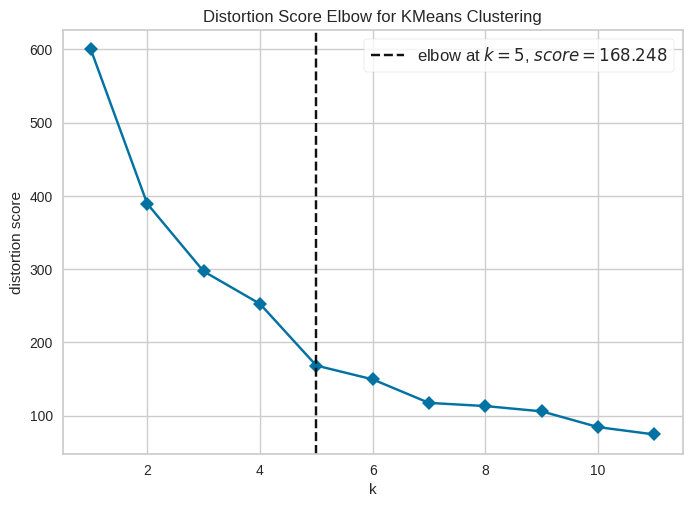

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [154]:
# Método del Codo con yellowbrick
model = KMeans(random_state=0)
visualizer = KElbowVisualizer(model, k=(1, 12), timings=False)
visualizer.fit(df)
visualizer.show(show=False)

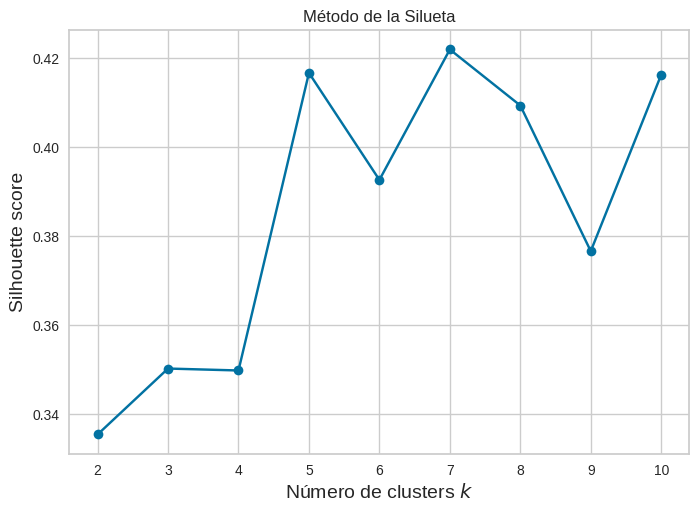

In [155]:
# Método de la Silueta
models = [KMeans(n_clusters=n, random_state=0).fit(df) for n in range(2, 11)]
silhouette_scores = [silhouette_score(df, model.labels_) for model in models]

plt.plot(list(range(2, 11)), silhouette_scores, 'bo-')
plt.xlabel('Número de clusters $k$', fontsize=14)
plt.ylabel('Silhouette score', fontsize=14)
plt.title('Método de la Silueta')
plt.show()

## <FONT SIZE=4 COLOR="green"> 5. K-means con k óptimo </FONT>

In [156]:
n = 5
kmeans_op = KMeans(n_clusters=n,                  #Número de clusters
                random_state=0)                #Semilla aleatoria.
kmeans_op.fit(df)

KMeans(n_clusters=5, random_state=0)

In [157]:
print(kmeans_op.inertia_)
print(kmeans_op.cluster_centers_)

168.2475801755683
[[ 1.20484056 -0.23577338 -0.05236781]
 [ 0.07333084  0.97494509 -1.19729675]
 [-0.42880597  0.97484722  1.21608539]
 [ 0.5310735  -1.2905084  -1.23646671]
 [-0.98067852 -0.74305983  0.46744035]]


In [158]:
df_cluster_op = df_num.copy()
df_cluster_op['cluster'] = kmeans_op.labels_
df_cluster_op.head(10)

,Age,Annual Income (k$),Spending Score (1-100),cluster
0,19,15,39,4
1,21,15,81,4
2,20,16,6,3
3,23,16,77,4
4,31,17,40,4
5,22,17,76,4
6,35,18,6,3
7,23,18,94,4
8,64,19,3,3
9,30,19,72,4


In [159]:
# Gráfico 3D
fig = px.scatter_3d(df_cluster_op,
                    x='Age',
                    y='Annual Income (k$)',
                    z='Spending Score (1-100)',
                    color='cluster',
                    title=f'K-means con k={n} — Vista 3D')
fig.show()

In [160]:
df_cluster_str_op = df_cluster_op.copy()
df_cluster_str_op['cluster'] = df_cluster_str['cluster'].astype("category")

variables_to_plot = ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']
subplot_titles = variables_to_plot + [''] # Add an empty string for the 4th subplot title

# Crear subplots de 2x2
fig = make_subplots(rows=2, cols=2, subplot_titles=subplot_titles)

# Boxplot para "Age"
fig_age = px.box(df_cluster_str, x='cluster', y='Age', color='cluster')
for trace in fig_age.data:
    fig.add_trace(trace, row=1, col=1)

# Boxplot para "Annual Income (k$)"
fig_income = px.box(df_cluster_str, x='cluster', y='Annual Income (k$)', color='cluster')
for trace in fig_income.data:
    fig.add_trace(trace, row=1, col=2)

# Boxplot para "Spending Score (1-100)"
fig_spending = px.box(df_cluster_str, x='cluster', y='Spending Score (1-100)', color='cluster')
for trace in fig_spending.data:
    fig.add_trace(trace, row=2, col=1)

# Actualizar layout
fig.update_layout(
    title_text=f"Boxplots de Variables por Cluster (k={n})",
    height=1000,
    width=1000,
    showlegend=False
)

fig.show()

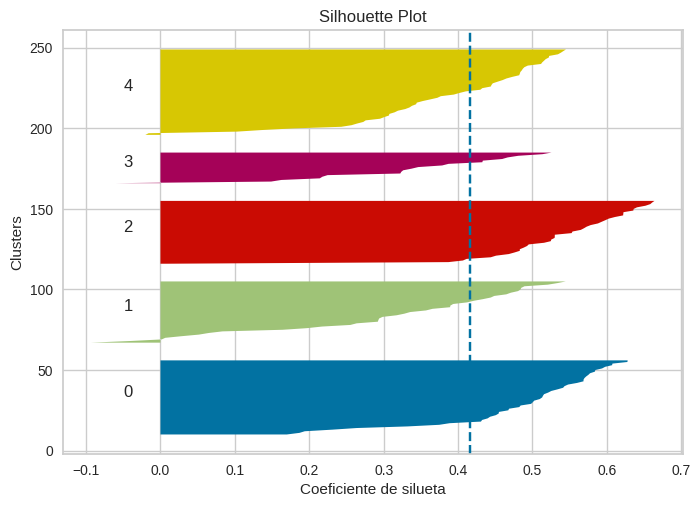

In [161]:
# Silhouette Plot
silhouette_avg = silhouette_score(df, kmeans_op.labels_)
sample_silhouette_values = silhouette_samples(df, kmeans_op.labels_)

fig, ax = plt.subplots()
y_lower = 10
for i in range(n):
    ith_cluster_values = sample_silhouette_values[kmeans_op.labels_ == i]
    ith_cluster_values.sort()
    size_cluster_i = ith_cluster_values.shape[0]
    y_upper = y_lower + size_cluster_i
    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, ith_cluster_values)
    ax.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))
    y_lower = y_upper + 10

ax.axvline(x=silhouette_avg, linestyle='--')
ax.set_title('Silhouette Plot')
ax.set_xlabel('Coeficiente de silueta')
ax.set_ylabel('Clusters')
plt.show()

## <FONT SIZE=4 COLOR="green"> 6. Representante de cada cluster y vecinos mas cercanos </FONT>:

In [162]:
# Representante: registro más cercano a cada centroide
closest, _ = pairwise_distances_argmin_min(kmeans_op.cluster_centers_, df)

for cluster_id, idx in enumerate(closest):
    print(f'\nCluster {cluster_id} — CustomerID: {clientes.loc[idx, "CustomerID"]}')
    print(df_num.iloc[idx])


Cluster 0 — CustomerID: 81
Age                       57
Annual Income (k$)        54
Spending Score (1-100)    51
Name: 80, dtype: int64

Cluster 1 — CustomerID: 167
Age                       42
Annual Income (k$)        86
Spending Score (1-100)    20
Name: 166, dtype: int64

Cluster 2 — CustomerID: 176
Age                       30
Annual Income (k$)        88
Spending Score (1-100)    86
Name: 175, dtype: int64

Cluster 3 — CustomerID: 35
Age                       49
Annual Income (k$)        33
Spending Score (1-100)    14
Name: 34, dtype: int64

Cluster 4 — CustomerID: 46
Age                       24
Annual Income (k$)        39
Spending Score (1-100)    65
Name: 45, dtype: int64


In [163]:
nn = NearestNeighbors(n_neighbors=5)
nn.fit(df)

for cluster_id, idx in enumerate(closest):
    punto = df.iloc[[idx]]
    distancias, indices = nn.kneighbors(punto)
    vecinos_idx = indices[0][1:]  # excluimos el propio punto
    print(f'\nCluster {cluster_id} (representante CustomerID {clientes.loc[idx, "CustomerID"]}):')
    print(f'Vecinos más cercanos CustomerID: {clientes.loc[vecinos_idx, "CustomerID"].values}')
    print(df_num.iloc[vecinos_idx])


Cluster 0 (representante CustomerID 81):
Vecinos más cercanos CustomerID: [75 73 74 87]
    Age  Annual Income (k$)  Spending Score (1-100)
74   59                  54                      47
72   60                  50                      49
73   60                  50                      56
86   55                  57                      58

Cluster 1 (representante CustomerID 167):
Vecinos más cercanos CustomerID: [171 151 153 155]
     Age  Annual Income (k$)  Spending Score (1-100)
170   40                  87                      13
150   43                  78                      17
152   44                  78                      20
154   47                  78                      16

Cluster 2 (representante CustomerID 176):
Vecinos más cercanos CustomerID: [162 182 164 184]
     Age  Annual Income (k$)  Spending Score (1-100)
161   29                  79                      83
181   32                  97                      86
163   31                  81           

## <FONT SIZE=4 COLOR="green"> 7. Repetir K-means incluyendo la variable gender </FONT>

In [164]:
le = LabelEncoder()
df_Gender = df_num.copy()
df_Gender['Gender'] = le.fit_transform(clientes['Gender'])

# Escalamos incluyendo gender
scaler2 = StandardScaler()
df_Gender_std = pd.DataFrame(scaler2.fit_transform(df_Gender),
                             columns=df_Gender.columns)

# K-means con el mismo k
kmeans_Gender = KMeans(n_clusters=n, random_state=0)
kmeans_Gender.fit(df_Gender_std)

print(f'Inercia con gender: {kmeans_Gender.inertia_:.2f}')
print(f'Silhouette Score con gender: {silhouette_score(df_Gender_std, kmeans_Gender.labels_):.4f}')

Inercia con gender: 331.26
Silhouette Score con gender: 0.3178


In [165]:
df_Gender_cluster = df_num.copy()
df_Gender_cluster['Gender'] = clientes['Gender']
df_Gender_cluster['cluster'] = kmeans_Gender.labels_.astype(str)

# Distribución de género por cluster
print(pd.crosstab(df_Gender_cluster['cluster'], df_Gender_cluster['Gender']))

Gender   Female  Male
cluster              
0             0    28
1            57     0
2            55     0
3             0    19
4             0    41


In [166]:
fig = px.histogram(df_Gender_cluster, x='cluster', color='Gender', barmode='group',
                   title=f'Distribución de Género por Cluster (k={n})')
fig.show()

In [167]:
fig = px.scatter_3d(df_Gender_cluster,
                    x='Age',
                    y='Annual Income (k$)',
                    z='Spending Score (1-100)',
                    color='cluster',
                    symbol='Gender',
                    title=f'K-means con Gender (k={n})')
fig.show()

## <FONT SIZE=4 COLOR="green"> 8. Análisis y Conclusiones </FONT>

**Conclusiones Sobre K-means:**

-El algoritmo logró segmentar exitosamente a los clientes en grupos con perfiles comerciales interpretables, lo cual tiene valor directo para estrategias de marketing.

-La combinación Elbow + Silhouette es una buena práctica para validar k  ninguno de los dos métodos debe usarse de forma aislada ya que esto nos ayudo a ver mejor y analizar nuestro modelo k means.

-La estandarización previa fue esencial: sin ella, Annual Income (valores en miles) habría dominado sobre Spending Score (0-100).

-El Silhouette Plot (Gráfico de Silueta por cluster) mostró que algunos lusters tienen coeficientes más bajos, indicando cierto solapamiento  esperable en datos reales de comportamiento humano.

# <FONT COLOR="Purple"> 2. PCA</FONT>

Conside los delitos en Colombia del año 2017.

```python
https://raw.githubusercontent.com/Fabian830348/Bases_Datos/refs/heads/master/Delitos_Colombia.csv
```



1. Cargar y explorar los datos

2. Hacer el analisis de PCA. Identificar las componentes.

3. Hacer el análisis de Biplot.

4. Concluya